<a href="https://colab.research.google.com/github/obieshka/Python-2025-/blob/hw_4/%D0%9F%D1%80%D0%B0%D0%BA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

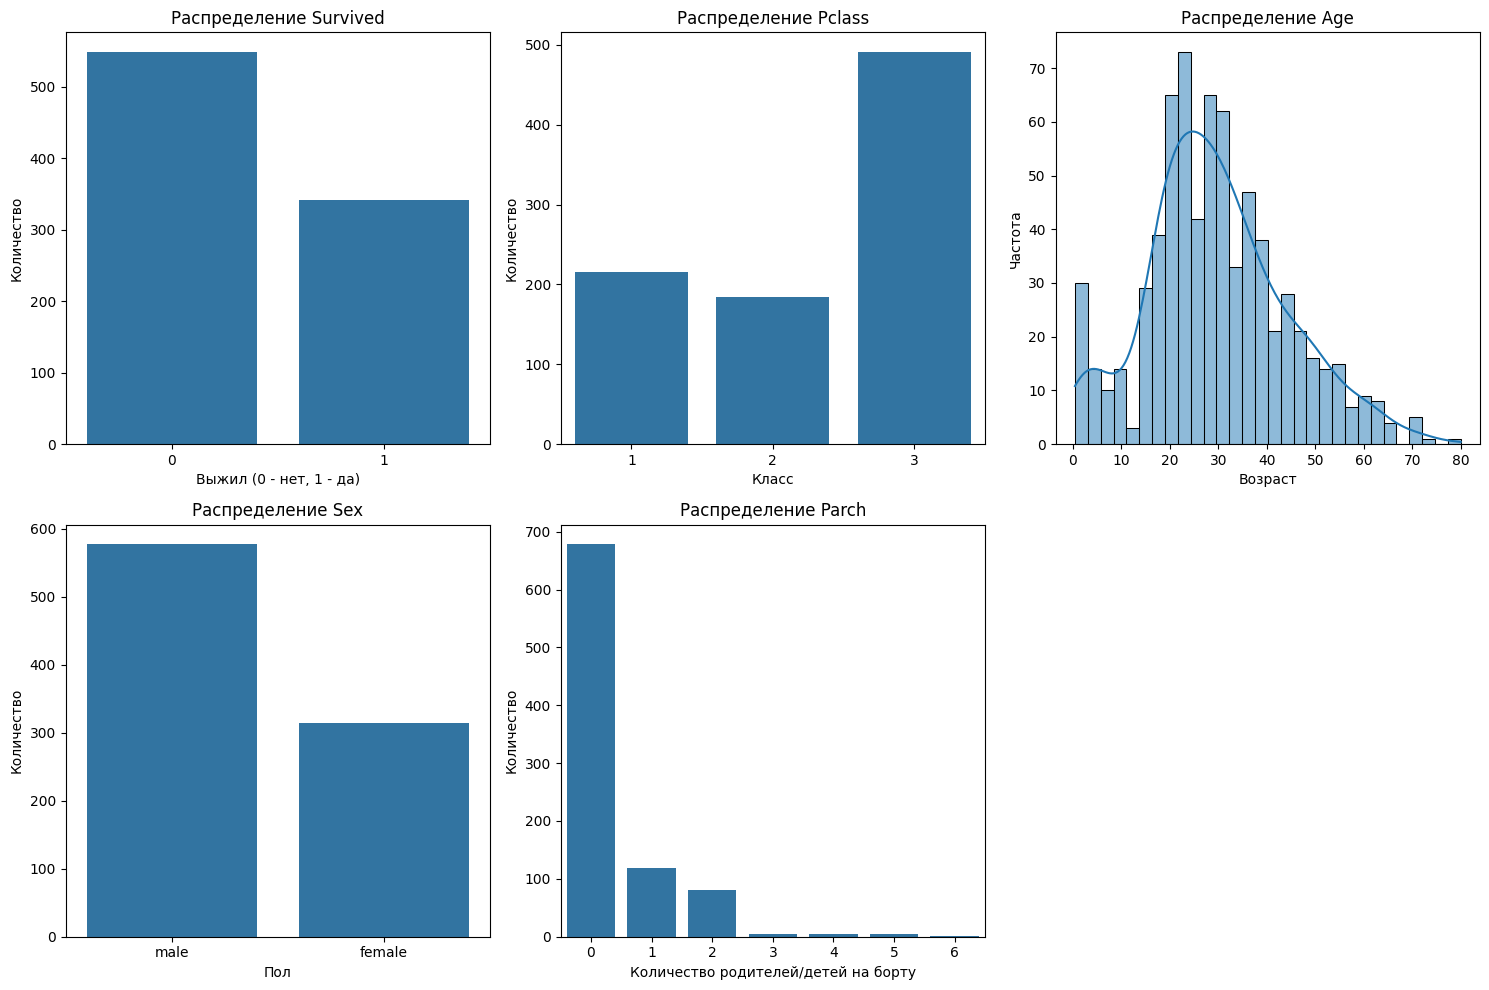

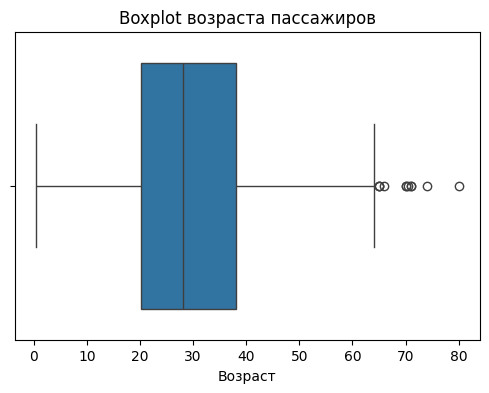

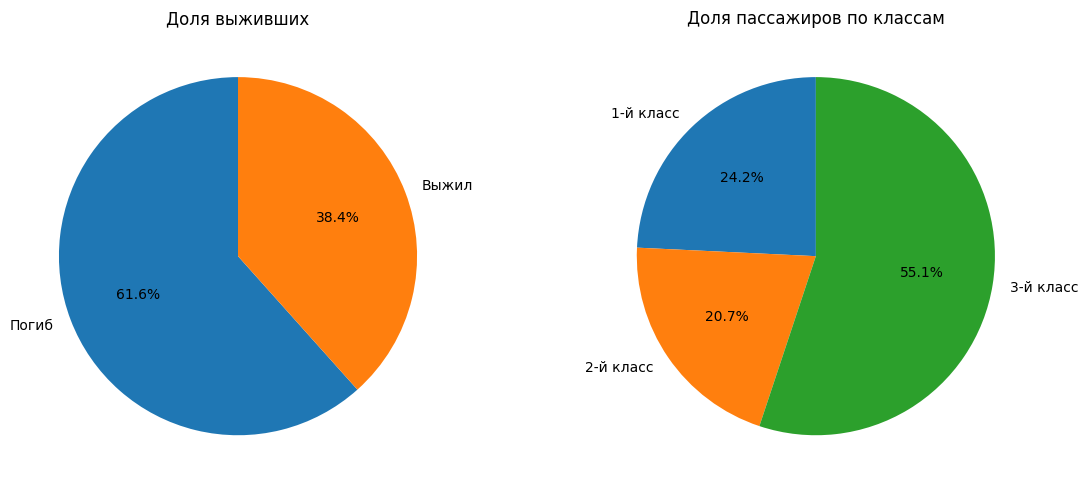

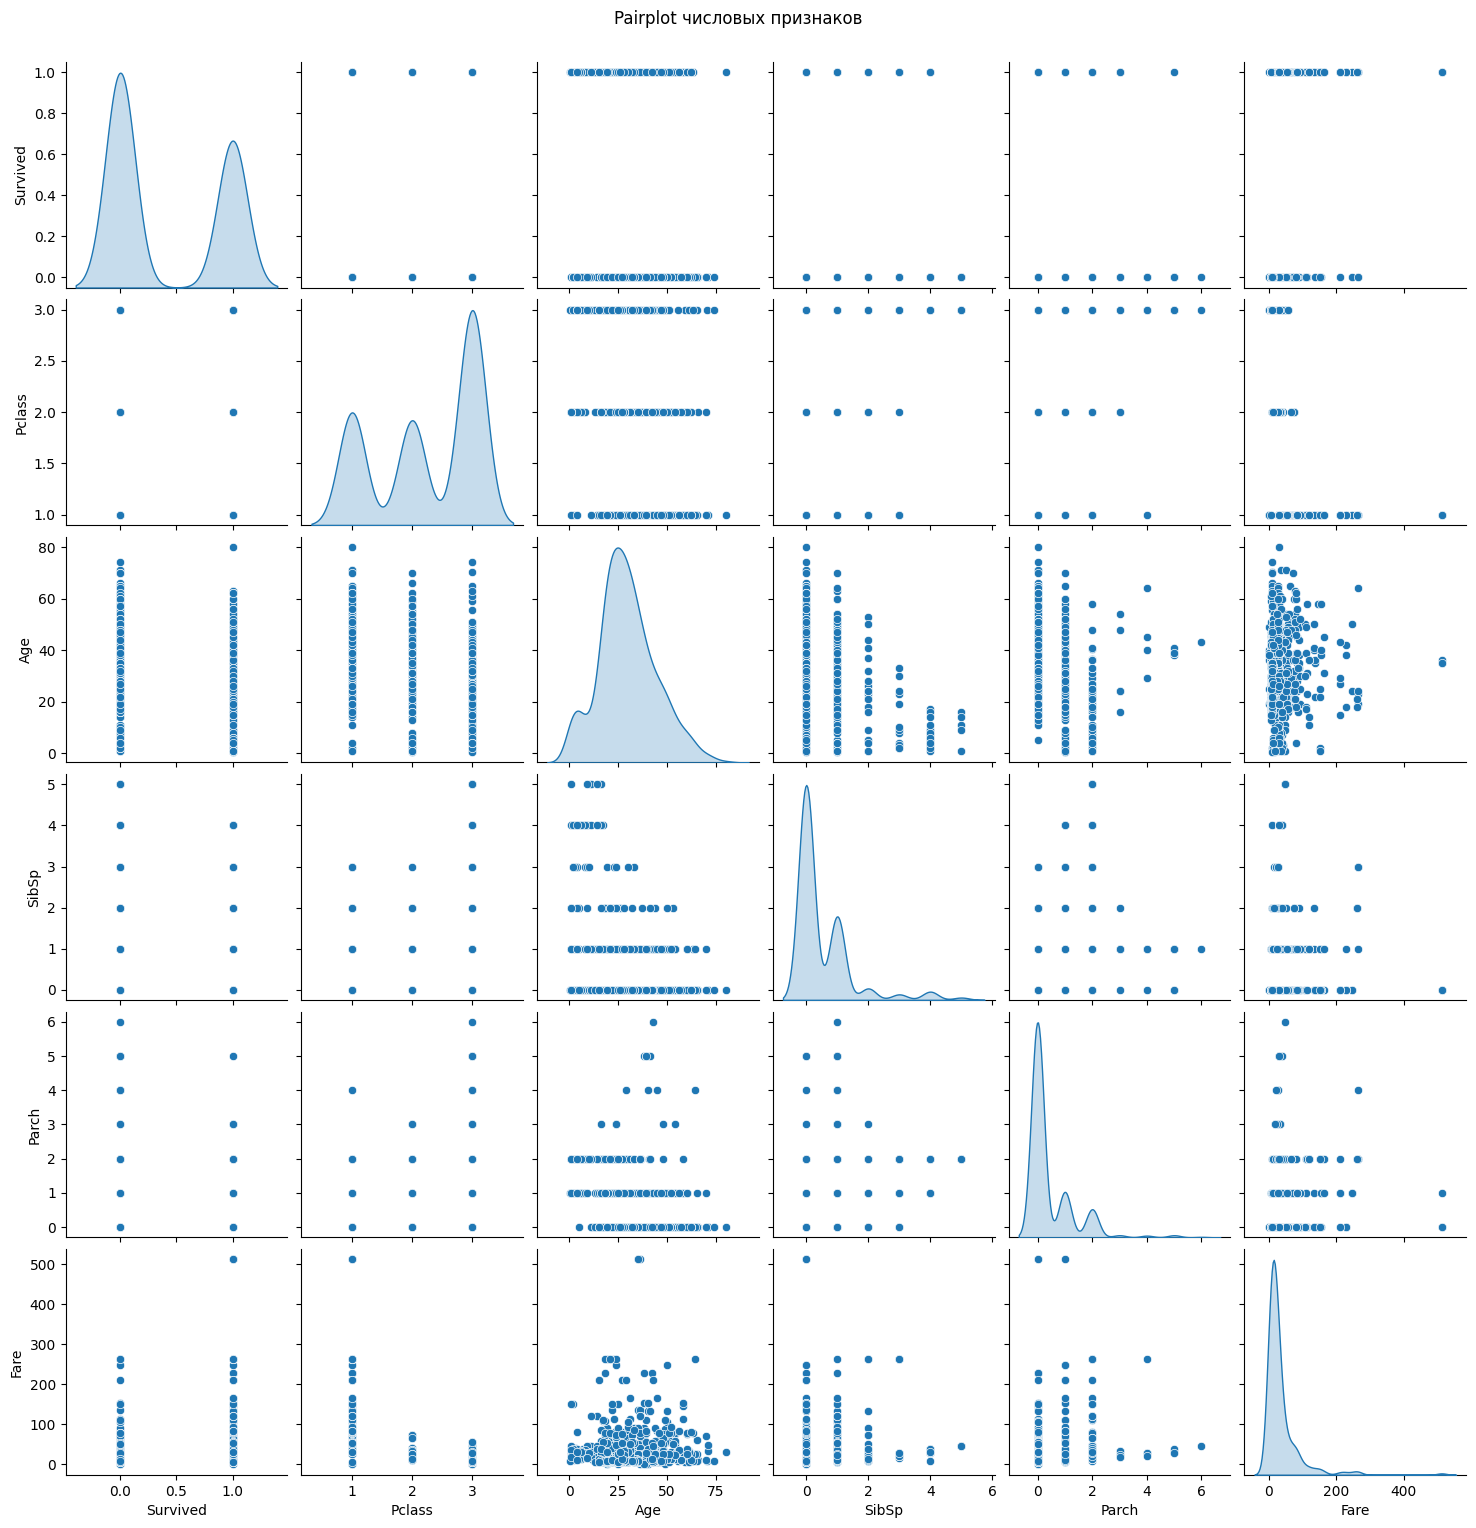

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('train.csv')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sns.countplot(x='Survived', data=df, ax=axes[0])
axes[0].set_title('Распределение Survived')
axes[0].set_xlabel('Выжил (0 - нет, 1 - да)')
axes[0].set_ylabel('Количество')

sns.countplot(x='Pclass', data=df, ax=axes[1])
axes[1].set_title('Распределение Pclass')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')

sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[2])
axes[2].set_title('Распределение Age')
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Частота')

sns.countplot(x='Sex', data=df, ax=axes[3])
axes[3].set_title('Распределение Sex')
axes[3].set_xlabel('Пол')
axes[3].set_ylabel('Количество')

sns.countplot(x='Parch', data=df, ax=axes[4])
axes[4].set_title('Распределение Parch')
axes[4].set_xlabel('Количество родителей/детей на борту')
axes[4].set_ylabel('Количество')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title('Boxplot возраста пассажиров')
plt.xlabel('Возраст')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

survived_counts = df['Survived'].value_counts()
ax1.pie(survived_counts, labels=['Погиб', 'Выжил'], autopct='%1.1f%%', startangle=90)
ax1.set_title('Доля выживших')

pclass_counts = df['Pclass'].value_counts().sort_index()
ax2.pie(pclass_counts, labels=['1-й класс', '2-й класс', '3-й класс'], autopct='%1.1f%%', startangle=90)
ax2.set_title('Доля пассажиров по классам')

plt.tight_layout()
plt.show()

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.pairplot(df[numeric_cols].dropna(), diag_kind='kde')
plt.suptitle('Pairplot числовых признаков', y=1.02)
plt.show()

sunburst_data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
fig_sunburst = px.sunburst(sunburst_data,
                           path=['Pclass', 'Sex'],
                           values='count',
                           title='Иерархия пассажиров: класс и пол',
                           color='Pclass',
                           color_continuous_scale='Blues')
fig_sunburst.show()